# SSNE - Mini Projekt 5
**autorzy**:
- Katarzyna Kanicka,
- Hanna Zarzycka

## Treść zadania

Zadanie polega na stworzeniu modelu rekurencyjnego który przewidywał będzie kompozytora danego utworu muzyki klasycznej w oparciu o jego zapis w formie sekwencji akordów. Akordy znormalizowane zostały do klucza C-dur lub a-mol w zależności od skali utworu (durowa/molowa).
Dane przygotowane są w postaci Pickli - https://docs.python.org/3/library/pickle.html w których znajduje się lista krotek z sekwencjami i odpowiadającymi im klasami - autorami odpowiednio: {0: 'bach', 1: 'beethoven', 2: 'debussy', 3: 'scarlatti', 4: 'victoria'} (train.pkl). W pliku test_no_target znajdują się testowe sekwencje, dla których predykcje mają Państwo przewidzieć.

Uwaga, utwory mogą być oczywiście różnych długości. W celu stworzenia batcha danych różnej długości, muszą je Państwo odpowiednio przygotować stosując tzw. padding. Przykładowo można się posiłkować tym tutorialem: https://suzyahyah.github.io/pytorch/2019/07/01/DataLoader-Pad-Pack-Sequence.html. W Państwa przypadku będzie to trochę łatwiejsze bo dotyczy problemu klasyfikacji sekwencji, a nie tłumaczenia sequence-to-sequence.

In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.3 MB/s eta 0:00:00


In [2]:
import torch
import random
import pickle
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
SEED = 28

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

## Przygotowanie danych

In [5]:
from google.colab import files
uploaded = files.upload()

Saving pakiet.zip to pakiet.zip


In [6]:
!unzip pakiet.zip -d /content/

Archive:  pakiet.zip
   creating: /content/pakiet/
  inflating: /content/__MACOSX/._pakiet  
  inflating: /content/pakiet/train.pkl  
  inflating: /content/__MACOSX/pakiet/._train.pkl  
  inflating: /content/pakiet/.DS_Store  
  inflating: /content/__MACOSX/pakiet/._.DS_Store  
  inflating: /content/pakiet/test_no_target.pkl  
  inflating: /content/__MACOSX/pakiet/._test_no_target.pkl  
  inflating: /content/pakiet/treść_zadania.txt  
  inflating: /content/__MACOSX/pakiet/._treść_zadania.txt  


In [7]:
with open("/content/pakiet/train.pkl", "rb") as f:
  train = pickle.load(f)

with open("/content/pakiet/test_no_target.pkl", "rb") as f:
  test = pickle.load(f)

In [8]:
point = train[0]

print(f"Sekwencja: {point[0]}")
print(f"Klasa: {point[1]}")

Sekwencja: [ -1.  -1.  -1. ...  78.  40. 144.]
Klasa: 0


In [9]:
len(train), len(test)

(2939, 1103)

In [10]:
X, y = zip(*train)

Text(0, 0.5, 'Ilość wystąpień')

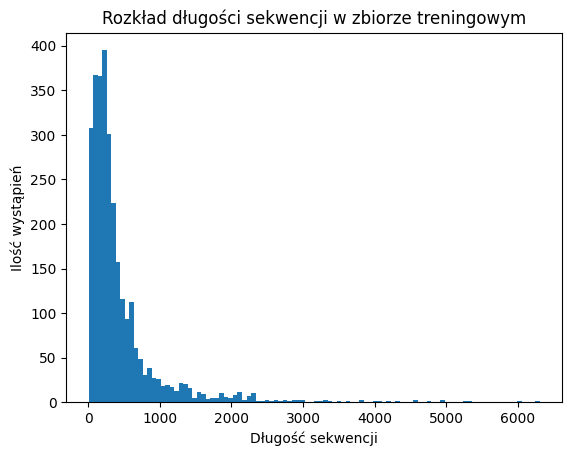

In [11]:
plt.hist([len(p) for p in X], bins=100)
plt.title('Rozkład długości sekwencji w zbiorze treningowym')
plt.xlabel('Długość sekwencji')
plt.ylabel('Ilość wystąpień')

Text(0, 0.5, 'Ilość wystąpień')

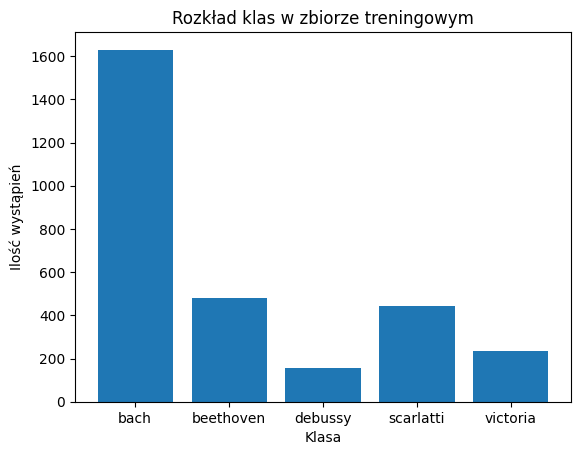

In [12]:
class_names = {0: 'bach', 1: 'beethoven', 2: 'debussy', 3: 'scarlatti', 4: 'victoria'}

y_np = np.array(y)

unique_classes, counts = np.unique(y_np, return_counts=True)
num_classes = 5

plt.bar(unique_classes, counts, tick_label=[class_names[c] for c in unique_classes], width=0.8, align='center')

plt.title('Rozkład klas w zbiorze treningowym')
plt.xlabel('Klasa')
plt.ylabel('Ilość wystąpień')


In [13]:
labels = ['bach', 'beethoven', 'debussy', 'scarlatti', 'victoria']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)


In [15]:
len(X_train), len(X_val), len(X_test)

(1763, 588, 588)

In [16]:
X_train_tensors = [torch.tensor(seq, dtype=torch.float32) for seq in X_train]
X_val_tensors = [torch.tensor(seq, dtype=torch.float32) for seq in X_val]
X_test_tensors = [torch.tensor(seq, dtype=torch.float32) for seq in X_test]

X_train_lengths = torch.tensor([len(seq) for seq in X_train], dtype=torch.long)
X_val_lengths = torch.tensor([len(seq) for seq in X_val], dtype=torch.long)
X_test_lengths = torch.tensor([len(seq) for seq in X_test], dtype=torch.long)

X_train_padded = pad_sequence(X_train_tensors, batch_first=True, padding_value=0)
X_val_padded = pad_sequence(X_val_tensors, batch_first=True, padding_value=0)
X_test_padded = pad_sequence(X_test_tensors, batch_first=True, padding_value=0)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

seq_len = len(X_train_padded[0])
seq_len

6308

In [17]:
train_dataset = data.TensorDataset(X_train_padded, X_train_lengths, y_train_tensor)
val_dataset = data.TensorDataset(X_val_padded, X_val_lengths, y_val_tensor)
test_dataset = data.TensorDataset(X_test_padded, X_test_lengths, y_test_tensor)

datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

In [18]:
datasets["train"][0]

(tensor([-1., -1., -1.,  ...,  0.,  0.,  0.]), tensor(36), tensor(0))

In [19]:
BATCH_SIZE = 64

dataloaders = {split: data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=0) for split in datasets}

## Trenowanie

In [20]:
import torchmetrics
import torch.nn as nn
from torch.utils.data import DataLoader

def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler, num_epochs: int):

    # Early stopping parameters
    best_val_loss = float('inf')
    patience = 5
    epochs_no_improve = 0
    best_model_weights = None

    # Metrics
    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    metrics = dict()
    # Run all epochs
    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            # Loop over each batch in the data loader
            for X_batch, lengths, target in tqdm(loaders[phase]):
                X_batch = X_batch.to(device)
                lengths = lengths.to(device)
                target = target.to(device).long()

                # Reset gradient
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X_batch, lengths)
                    _, preds = torch.max(logits, dim=1)
                    loss = criterion(logits, target)

                    metric_loss(loss)
                    metric_acc(logits, target)

                    # Backward
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            # Statistics for batch
            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            current_lr = lr_scheduler.get_last_lr()[0]
            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
            if epoch not in metrics:
              metrics[epoch] = {}
            metrics[epoch][f"loss {phase}"] = mean_loss.item()
            metrics[epoch][f"accuracy {phase}"] = acc.item()

            # Early stopping
            if phase == 'val':
                val_loss = mean_loss.item()

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    best_model_weights = model.state_dict()
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print(f"\nEarly stopping at epoch {epoch}")
                    model.load_state_dict(best_model_weights)
                    return metrics

            metric_loss.reset()
            metric_acc.reset()

        lr_scheduler.step()
    return metrics

In [21]:
def plot_training_curves(metrics):
    epochs = sorted(metrics.keys())

    train_loss = [metrics[e]["loss train"] for e in epochs]
    val_loss = [metrics[e]["loss val"] for e in epochs]
    train_acc = [metrics[e]["accuracy train"] for e in epochs]
    val_acc = [metrics[e]["accuracy val"] for e in epochs]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)

In [22]:
def get_predictions(model, dataloader, device):
    preds_l = []
    targets_l = []

    model.eval()

    for input_ids, lengths, target in dataloader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        target = target.to(device)

        with torch.inference_mode():
            logits = model(input_ids, lengths)
            _, preds = torch.max(logits, dim=-1)

        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

    preds = np.array(preds_l)
    targets = np.array(targets_l)

    return preds, targets

### LSTM base

In [ ]:
class LSTMClassifier(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = x.unsqueeze(-1)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, cell) = self.lstm(packed_x)
        x = hidden[-1]
        # x = self.bn(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
weights = torch.tensor([
    1/326,
    1/96,
    1/31,
    1/88,
    1/47
], dtype=torch.float32).to(device)

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

num_epochs = 20

model = LSTMClassifier(1,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(model, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 28/28 [00:05<00:00,  5.23it/s]


(Epoch 1/[train]) Loss:	1.601   Accuracy: 0.201   lr: 0.0005


100%|██████████| 10/10 [00:00<00:00, 15.93it/s]


(Epoch 1/[val]) Loss:	1.581   Accuracy: 0.177   lr: 0.0005


100%|██████████| 28/28 [00:05<00:00,  5.28it/s]


...

(Epoch 19/[val]) Loss:	1.155   Accuracy: 0.573   lr: 2.199115350768739e-05


100%|██████████| 28/28 [00:04<00:00,  5.96it/s]


(Epoch 20/[train]) Loss:	1.088   Accuracy: 0.575   lr: 1.3016356554191275e-05


100%|██████████| 10/10 [00:00<00:00, 15.23it/s]

(Epoch 20/[val]) Loss:	1.159   Accuracy: 0.585   lr: 1.3016356554191275e-05


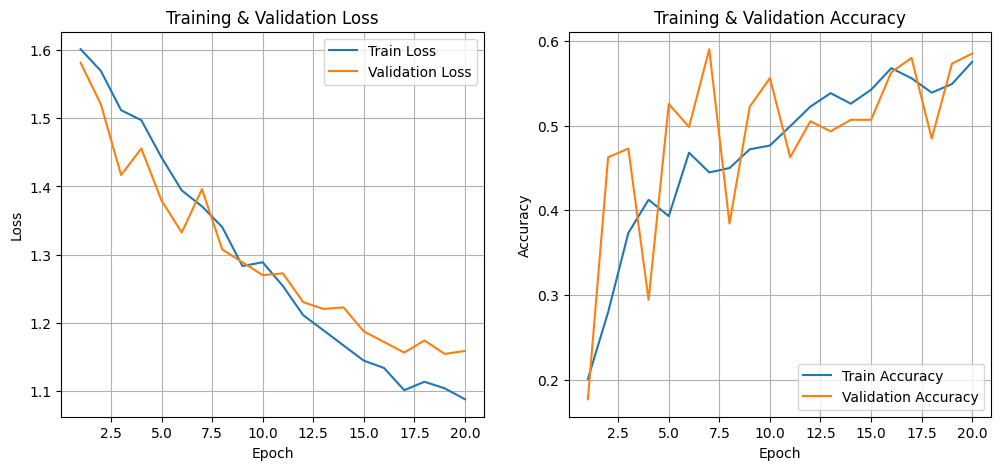

In [ ]:
plot_training_curves(metrics)

In [ ]:
labels = ['bach', 'beethoven', 'debussy', 'scarlatti', 'victoria']
preds, targets = get_predictions(model, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.84      0.65      0.73       326
   beethoven       0.54      0.39      0.45        96
     debussy       0.23      0.61      0.33        31
   scarlatti       0.57      0.49      0.53        88
    victoria       0.33      0.77      0.46        47

    accuracy                           0.59       588
   macro avg       0.50      0.58      0.50       588
weighted avg       0.68      0.59      0.61       588



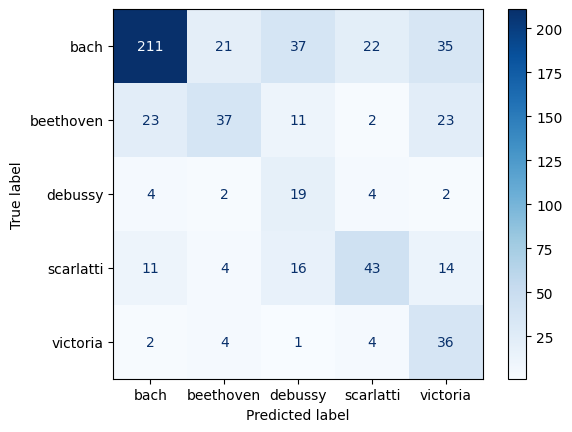

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### Inne wagi

In [23]:
skl_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
print(skl_weights)

weights_sqrt = np.sqrt(skl_weights)
print(weights_sqrt)

[0.3606135  1.22970711 3.81688312 1.33287982 2.49067797]
[0.60051103 1.1089216  1.9536845  1.15450414 1.57818819]


In [24]:
weights = torch.FloatTensor(skl_weights).cuda()

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

num_epochs = 20

model = LSTMClassifier(1,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(model, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 28/28 [00:04<00:00,  5.61it/s]


(Epoch 1/[train]) Loss:	1.601   Accuracy: 0.201   lr: 0.0005


100%|██████████| 10/10 [00:00<00:00, 11.08it/s]


(Epoch 1/[val]) Loss:	1.581   Accuracy: 0.184   lr: 0.0005


100%|██████████| 28/28 [00:05<00:00,  5.52it/s]


...

(Epoch 19/[val]) Loss:	1.196   Accuracy: 0.556   lr: 2.199115350768739e-05


100%|██████████| 28/28 [00:05<00:00,  5.35it/s]


(Epoch 20/[train]) Loss:	1.088   Accuracy: 0.576   lr: 1.3016356554191275e-05


100%|██████████| 10/10 [00:00<00:00, 14.66it/s]

(Epoch 20/[val]) Loss:	1.185   Accuracy: 0.549   lr: 1.3016356554191275e-05


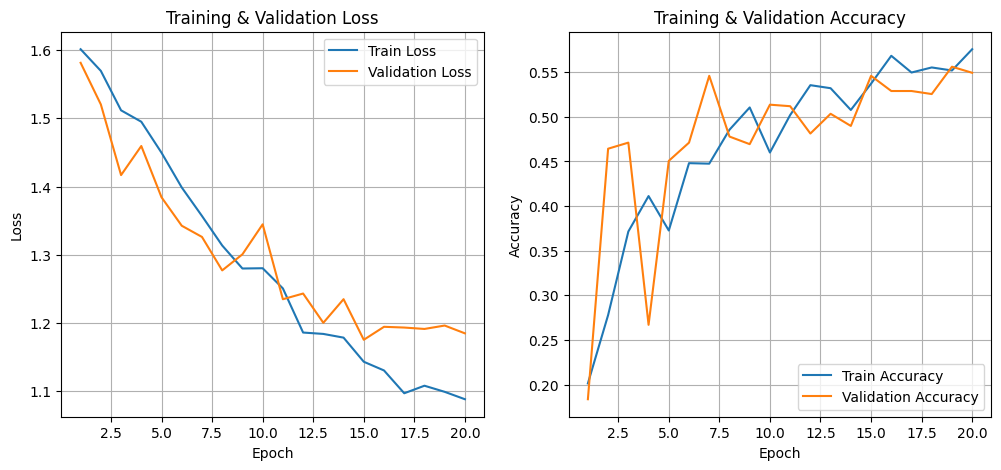

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.86      0.62      0.72       326
   beethoven       0.53      0.42      0.47        96
     debussy       0.25      0.58      0.35        31
   scarlatti       0.52      0.52      0.52        88
    victoria       0.33      0.81      0.47        47

    accuracy                           0.59       588
   macro avg       0.50      0.59      0.51       588
weighted avg       0.68      0.59      0.61       588



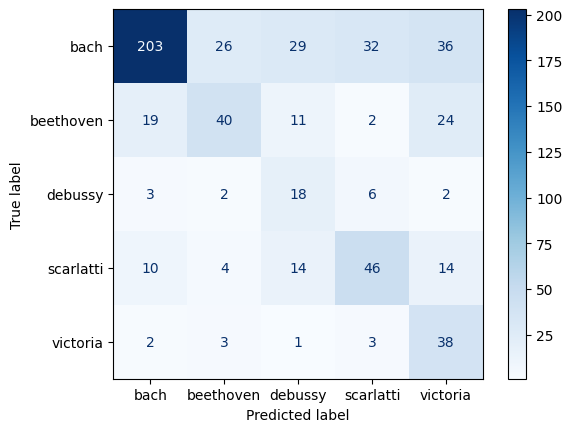

In [ ]:
cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### Zwiększenie hidden_size

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

num_epochs = 20

model = LSTMClassifier(1,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(model, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 28/28 [00:10<00:00,  2.69it/s]


(Epoch 1/[train]) Loss:	1.601   Accuracy: 0.269   lr: 0.0005


100%|██████████| 10/10 [00:01<00:00,  8.17it/s]


(Epoch 1/[val]) Loss:	1.570   Accuracy: 0.211   lr: 0.0005


100%|██████████| 28/28 [00:09<00:00,  2.92it/s]


...

(Epoch 19/[val]) Loss:	1.064   Accuracy: 0.605   lr: 2.199115350768739e-05


100%|██████████| 28/28 [00:05<00:00,  5.08it/s]


(Epoch 20/[train]) Loss:	0.869   Accuracy: 0.651   lr: 1.3016356554191275e-05


100%|██████████| 10/10 [00:00<00:00, 14.69it/s]

(Epoch 20/[val]) Loss:	1.061   Accuracy: 0.590   lr: 1.3016356554191275e-05


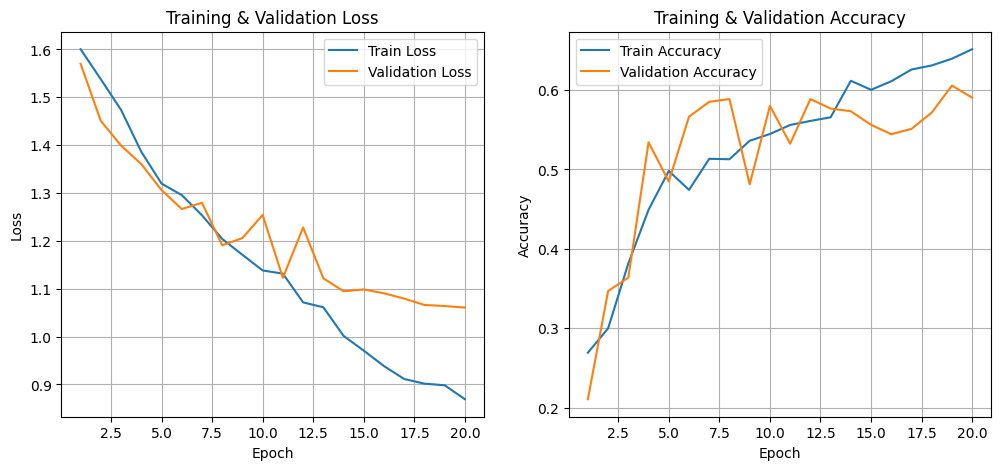

In [ ]:
plot_training_curves(metrics)

In [ ]:
labels = ['bach', 'beethoven', 'debussy', 'scarlatti', 'victoria']
preds, targets = get_predictions(model, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.88      0.65      0.75       326
   beethoven       0.56      0.49      0.52        96
     debussy       0.31      0.61      0.41        31
   scarlatti       0.46      0.53      0.49        88
    victoria       0.41      0.87      0.55        47

    accuracy                           0.62       588
   macro avg       0.52      0.63      0.55       588
weighted avg       0.70      0.62      0.64       588



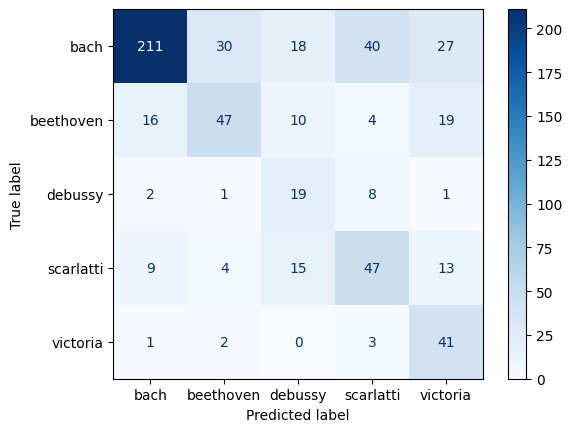

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### Zmniejszenie batch_size

In [ ]:
BATCH_SIZE = 32

dataloaders = {split: data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=0) for split in datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

num_epochs = 20

model = LSTMClassifier(1,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(model, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 56/56 [00:09<00:00,  5.86it/s]


(Epoch 1/[train]) Loss:	1.591   Accuracy: 0.290   lr: 0.00025


100%|██████████| 19/19 [00:00<00:00, 19.17it/s]


(Epoch 1/[val]) Loss:	1.566   Accuracy: 0.250   lr: 0.00025


100%|██████████| 56/56 [00:09<00:00,  5.62it/s]


...

(Epoch 19/[val]) Loss:	1.131   Accuracy: 0.575   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:08<00:00,  6.49it/s]


(Epoch 20/[train]) Loss:	0.961   Accuracy: 0.622   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:01<00:00, 18.79it/s]

(Epoch 20/[val]) Loss:	1.140   Accuracy: 0.597   lr: 1.1477399128583483e-05


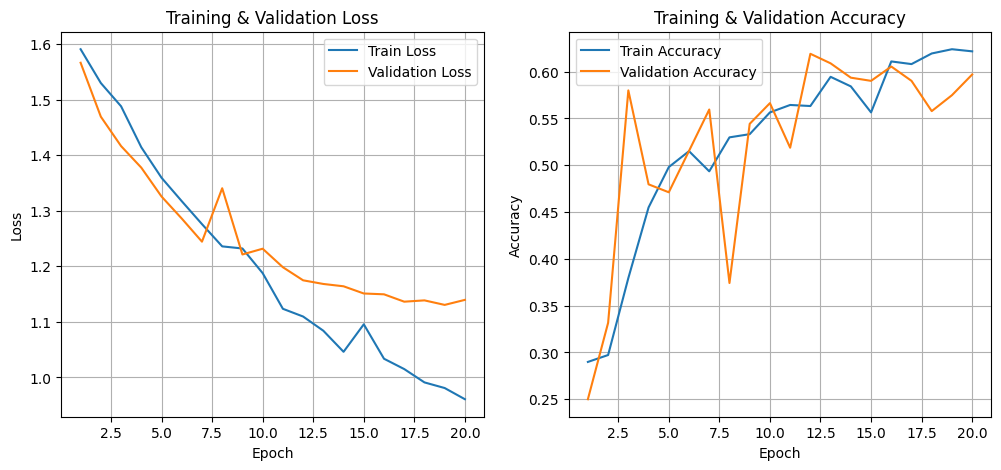

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.85      0.71      0.77       326
   beethoven       0.58      0.47      0.52        96
     debussy       0.30      0.52      0.38        31
   scarlatti       0.53      0.45      0.49        88
    victoria       0.36      0.83      0.50        47

    accuracy                           0.63       588
   macro avg       0.52      0.60      0.53       588
weighted avg       0.69      0.63      0.65       588



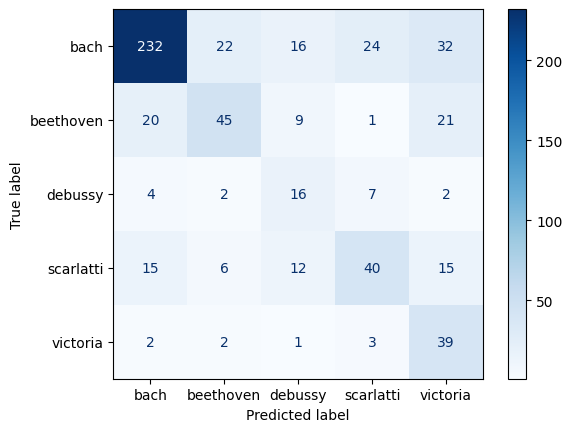

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### Dodanie embeddingów

In [ ]:
class LSTMClassifierV2(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.3 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed_x)

        x = hidden[-1]
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

model = LSTMClassifierV2(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

NameError: name 'LSTMClassifierV2' is not defined

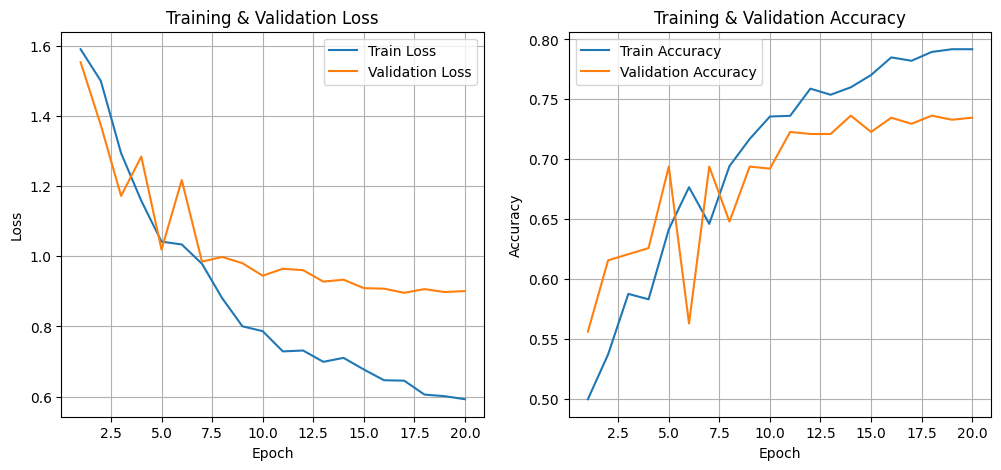

In [ ]:
plot_training_curves(metrics)

In [ ]:
labels = ['bach', 'beethoven', 'debussy', 'scarlatti', 'victoria']
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.94      0.86      0.90       326
   beethoven       0.55      0.66      0.60        96
     debussy       0.35      0.55      0.42        31
   scarlatti       0.71      0.58      0.64        88
    victoria       0.74      0.83      0.78        47

    accuracy                           0.77       588
   macro avg       0.66      0.69      0.67       588
weighted avg       0.79      0.77      0.77       588



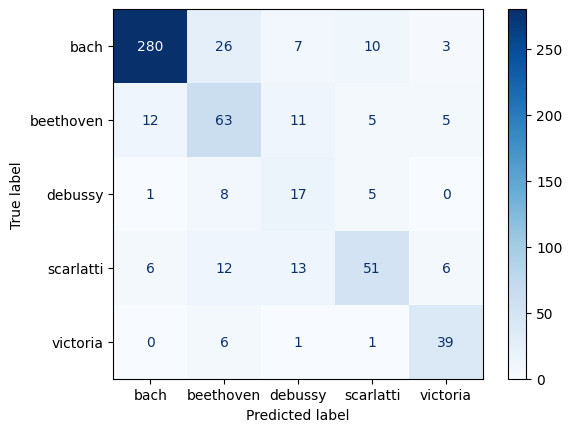

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### Embeddingi + dwukierunkowość

In [ ]:
class LSTMClassifierV3(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True, dropout=0.4 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed_x)

        hidden = hidden.view(self.num_layers, 2, x.size(0), self.hidden_size)

        forward_hidden = hidden[-1, 0, :, :]
        backward_hidden = hidden[-1, 1, :, :]

        x = torch.cat((forward_hidden, backward_hidden), dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [25]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV3(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:19<00:00,  2.94it/s]


(Epoch 1/[train]) Loss:	1.542   Accuracy: 0.351   lr: 0.00025


100%|██████████| 19/19 [00:04<00:00,  4.38it/s]


(Epoch 1/[val]) Loss:	1.352   Accuracy: 0.617   lr: 0.00025


100%|██████████| 56/56 [00:20<00:00,  2.73it/s]


...

(Epoch 19/[val]) Loss:	0.761   Accuracy: 0.827   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:16<00:00,  3.40it/s]


(Epoch 20/[train]) Loss:	0.191   Accuracy: 0.929   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:02<00:00,  9.32it/s]

(Epoch 20/[val]) Loss:	0.765   Accuracy: 0.827   lr: 1.1477399128583483e-05


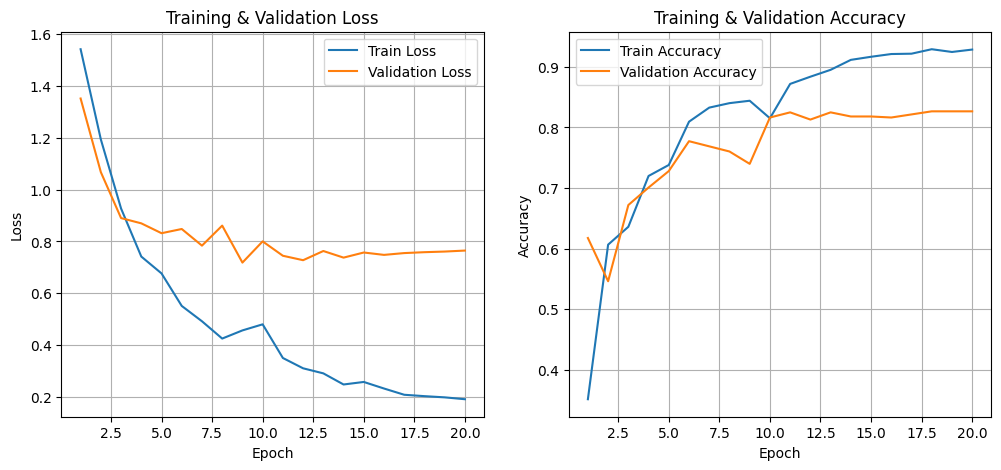

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.94      0.92      0.93       326
   beethoven       0.73      0.76      0.74        96
     debussy       0.71      0.65      0.68        31
   scarlatti       0.80      0.80      0.80        88
    victoria       0.84      0.91      0.88        47

    accuracy                           0.86       588
   macro avg       0.80      0.81      0.81       588
weighted avg       0.86      0.86      0.86       588



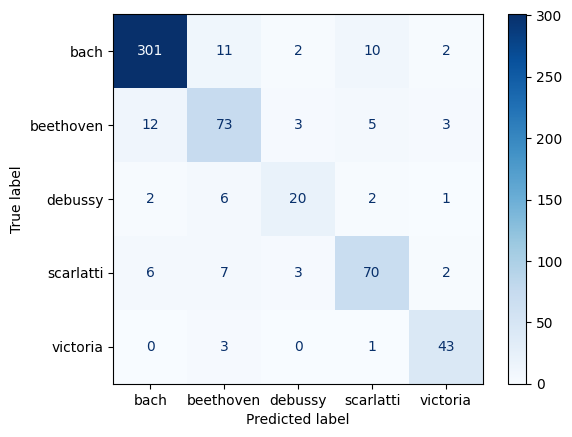

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### LSTM + mean

In [ ]:
class LSTMClassifierV4(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True, dropout=0.4 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] < lengths[:, None]
        mask = mask.unsqueeze(-1).float()
        out = out * mask
        x = out.sum(dim=1) / lengths.unsqueeze(1).float()

        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV4(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:33<00:00,  1.69it/s]


(Epoch 1/[train]) Loss:	1.440   Accuracy: 0.509   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  8.45it/s]


(Epoch 1/[val]) Loss:	1.068   Accuracy: 0.634   lr: 0.00025


100%|██████████| 56/56 [00:28<00:00,  1.94it/s]


...

(Epoch 19/[val]) Loss:	0.461   Accuracy: 0.869   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:24<00:00,  2.32it/s]


(Epoch 20/[train]) Loss:	0.127   Accuracy: 0.956   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:02<00:00,  7.24it/s]

(Epoch 20/[val]) Loss:	0.475   Accuracy: 0.867   lr: 1.1477399128583483e-05


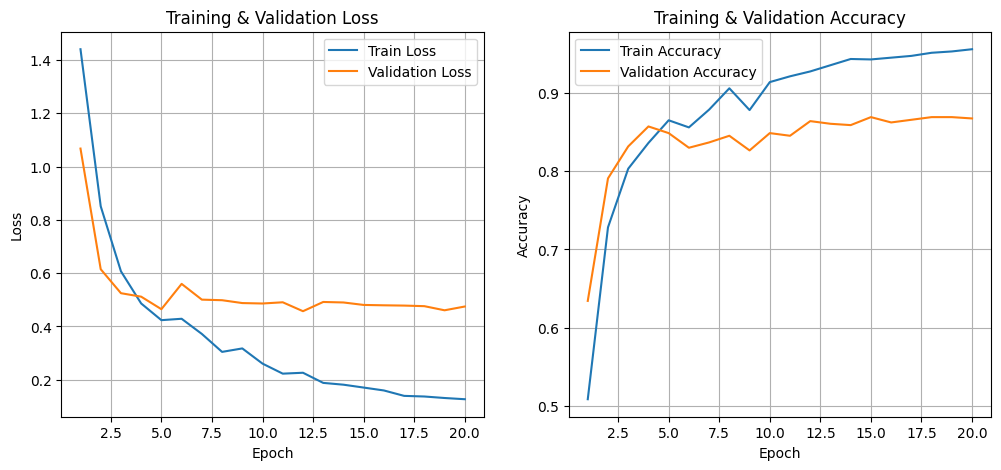

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.93      0.95       326
   beethoven       0.79      0.80      0.79        96
     debussy       0.76      0.90      0.82        31
   scarlatti       0.80      0.83      0.82        88
    victoria       0.92      0.94      0.93        47

    accuracy                           0.89       588
   macro avg       0.85      0.88      0.86       588
weighted avg       0.90      0.89      0.90       588



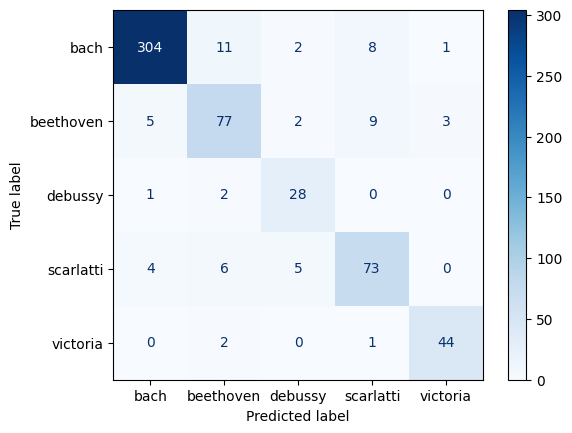

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

In [ ]:
# Zwiększenie weight_decay, zmniejszenie hidden_size

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV4(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-1)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:17<00:00,  3.12it/s]


(Epoch 1/[train]) Loss:	1.552   Accuracy: 0.605   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00, 10.09it/s]


(Epoch 1/[val]) Loss:	1.425   Accuracy: 0.636   lr: 0.00025


100%|██████████| 56/56 [00:16<00:00,  3.30it/s]


...

(Epoch 19/[val]) Loss:	0.372   Accuracy: 0.867   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:16<00:00,  3.33it/s]


(Epoch 20/[train]) Loss:	0.215   Accuracy: 0.942   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:02<00:00,  7.92it/s]

(Epoch 20/[val]) Loss:	0.371   Accuracy: 0.871   lr: 1.1477399128583483e-05


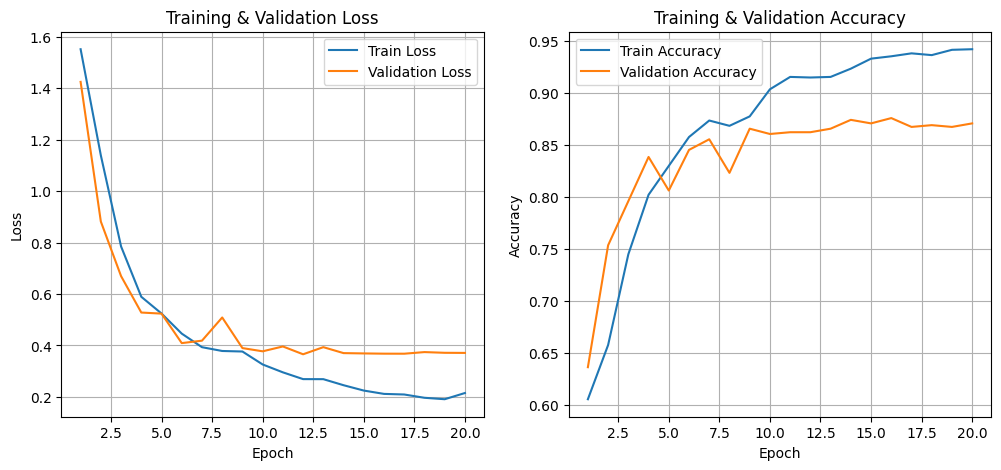

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.93      0.95       326
   beethoven       0.81      0.86      0.83        96
     debussy       0.77      0.97      0.86        31
   scarlatti       0.79      0.78      0.79        88
    victoria       0.96      0.96      0.96        47

    accuracy                           0.90       588
   macro avg       0.86      0.90      0.88       588
weighted avg       0.91      0.90      0.90       588



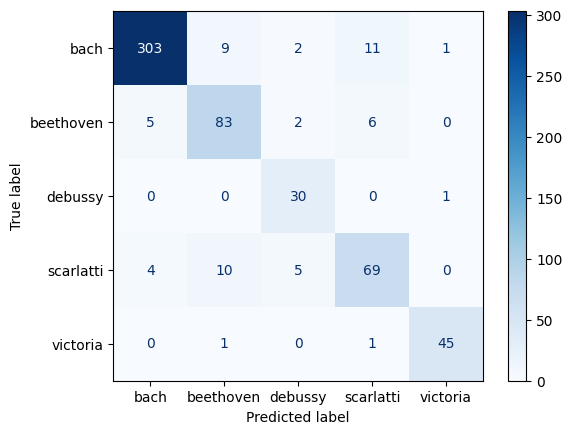

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### LSTM + max

In [ ]:
class LSTMClassifierV5(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True, dropout=0.4 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] < lengths[:, None]
        mask = mask.unsqueeze(-1).float()

        out = out.masked_fill(~mask.bool(), float('-inf'))
        x = out.max(dim=1).values

        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV5(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-1)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:18<00:00,  3.10it/s]


(Epoch 1/[train]) Loss:	1.580   Accuracy: 0.395   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.97it/s]


(Epoch 1/[val]) Loss:	1.526   Accuracy: 0.687   lr: 0.00025


100%|██████████| 56/56 [00:16<00:00,  3.32it/s]


...

(Epoch 19/[val]) Loss:	0.362   Accuracy: 0.879   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:17<00:00,  3.28it/s]


(Epoch 20/[train]) Loss:	0.242   Accuracy: 0.928   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:02<00:00,  7.95it/s]

(Epoch 20/[val]) Loss:	0.363   Accuracy: 0.878   lr: 1.1477399128583483e-05


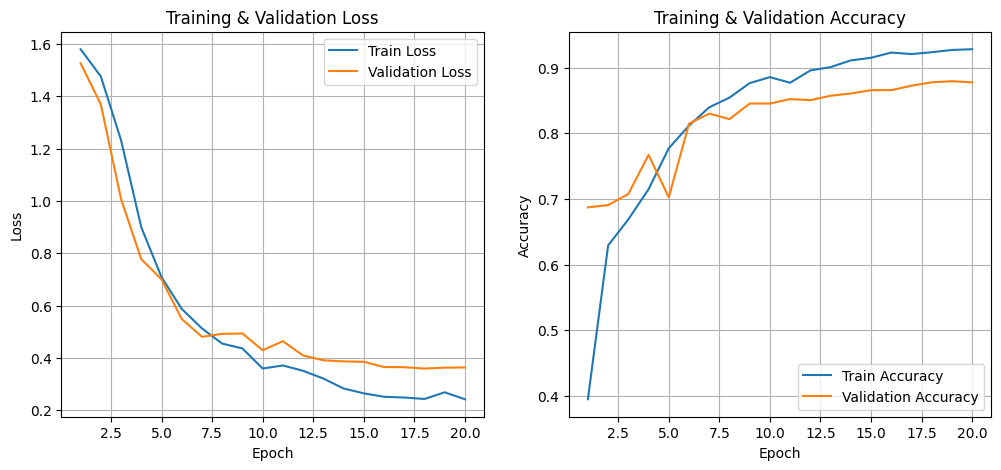

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.95      0.90      0.93       326
   beethoven       0.72      0.77      0.74        96
     debussy       0.77      0.97      0.86        31
   scarlatti       0.82      0.77      0.80        88
    victoria       0.85      0.98      0.91        47

    accuracy                           0.87       588
   macro avg       0.82      0.88      0.85       588
weighted avg       0.88      0.87      0.87       588



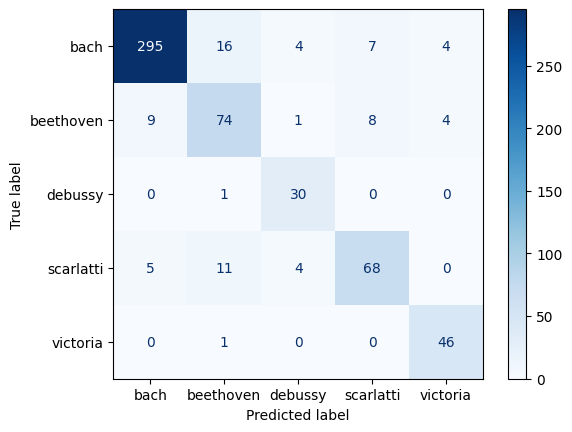

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### LSTM + mean + attention

In [ ]:
class LSTMClassifierV6(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)

        self.attention = nn.Linear(hidden_size * 2, 1)
        self.norm = nn.LayerNorm(hidden_size * 2)

        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(hidden_size*2, hidden_size)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        scores = self.attention(out).squeeze(-1)

        mask = torch.arange(out.size(1), device=lengths.device)[None, :] >= lengths[:, None]
        scores = scores.masked_fill(mask, float('-inf'))

        weights = torch.softmax(scores, dim=1)
        x = torch.sum(out * weights.unsqueeze(-1), dim=1)

        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV6(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-2)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

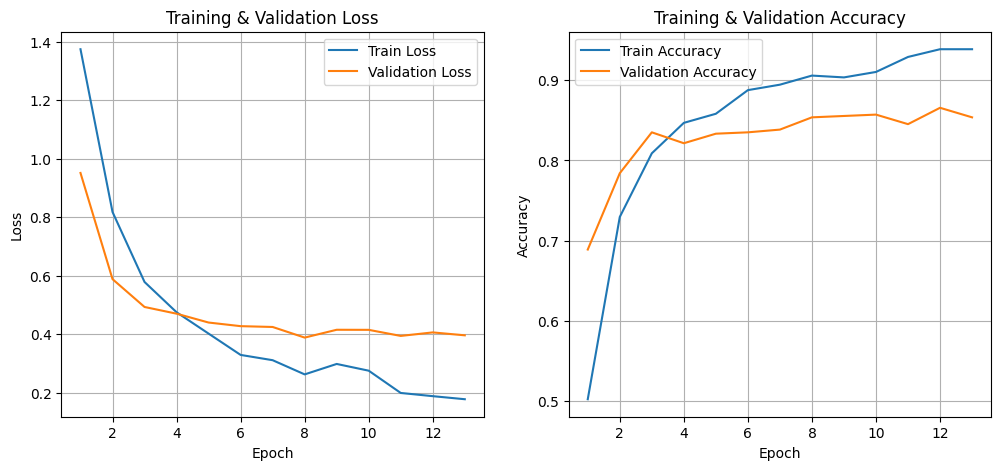

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.90      0.93       326
   beethoven       0.75      0.85      0.80        96
     debussy       0.86      0.97      0.91        31
   scarlatti       0.81      0.83      0.82        88
    victoria       0.88      0.96      0.92        47

    accuracy                           0.89       588
   macro avg       0.85      0.90      0.88       588
weighted avg       0.90      0.89      0.89       588



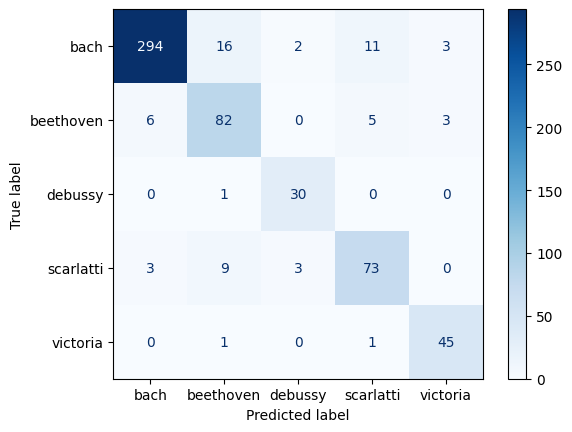

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### LSTM + mean + max

In [ ]:
class LSTMClassifierV7(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True, dropout=0.4 if num_layers > 1 else 0.0)

        self.norm = nn.LayerNorm(hidden_size * 4)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(hidden_size * 4, hidden_size)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        mask = (torch.arange(out.size(1), device=lengths.device)[None, :] < lengths[:, None]).unsqueeze(-1)

        masked_out = out * mask
        mean_pool = masked_out.sum(dim=1) / lengths.unsqueeze(-1).to(out.dtype)

        min_filled_out = out.masked_fill(~mask, -1e9)
        max_pool, _ = torch.max(min_filled_out, dim=1)

        x = torch.cat([mean_pool, max_pool], dim=-1)

        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = LSTMClassifierV7(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-2)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:23<00:00,  2.41it/s]


(Epoch 1/[train]) Loss:	1.504   Accuracy: 0.399   lr: 0.00025


100%|██████████| 19/19 [00:03<00:00,  4.78it/s]


(Epoch 1/[val]) Loss:	1.235   Accuracy: 0.697   lr: 0.00025


100%|██████████| 56/56 [00:20<00:00,  2.68it/s]


...

(Epoch 19/[val]) Loss:	0.373   Accuracy: 0.879   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:18<00:00,  3.07it/s]


(Epoch 20/[train]) Loss:	0.196   Accuracy: 0.934   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:02<00:00,  9.49it/s]

(Epoch 20/[val]) Loss:	0.380   Accuracy: 0.874   lr: 1.1477399128583483e-05

Early stopping at epoch 20


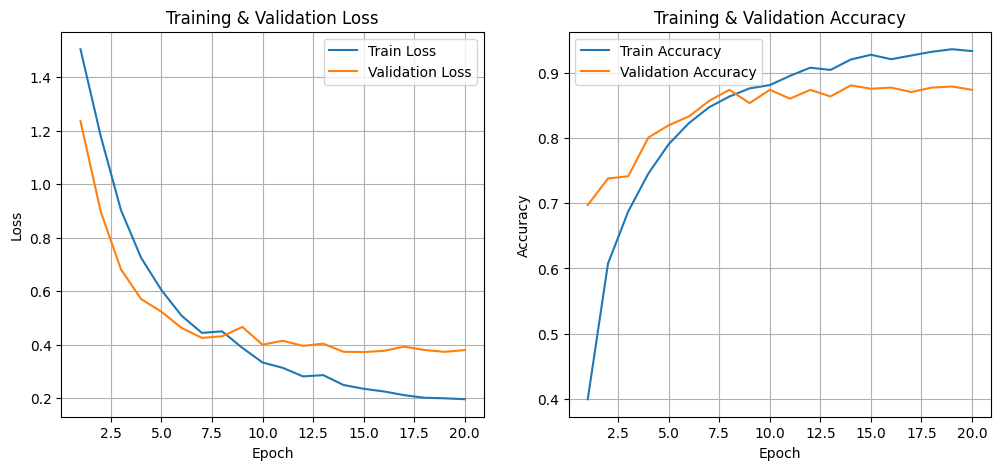

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.93      0.95       326
   beethoven       0.75      0.78      0.77        96
     debussy       0.88      0.97      0.92        31
   scarlatti       0.77      0.80      0.78        88
    victoria       0.88      0.96      0.92        47

    accuracy                           0.89       588
   macro avg       0.85      0.89      0.87       588
weighted avg       0.89      0.89      0.89       588



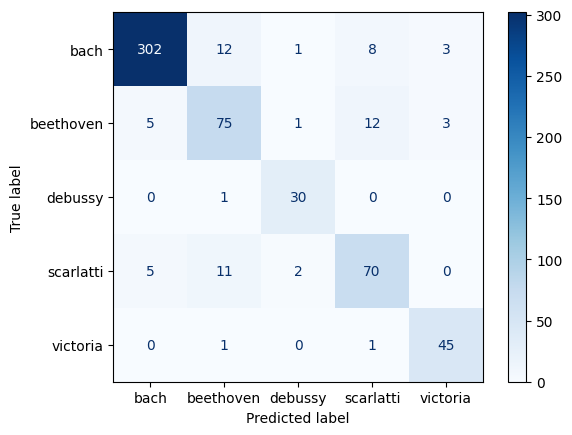

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU base

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed_x)
        hidden = hidden.view(self.num_layers, 2, x.size(0), self.hidden_size)

        forward_hidden = hidden[-1, 0, :, :]
        backward_hidden = hidden[-1, 1, :, :]

        x = torch.cat((forward_hidden, backward_hidden), dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifier(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=30)

100%|██████████| 56/56 [00:17<00:00,  3.24it/s]


(Epoch 1/[train]) Loss:	1.455   Accuracy: 0.450   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.55it/s]


(Epoch 1/[val]) Loss:	1.261   Accuracy: 0.616   lr: 0.00025


100%|██████████| 56/56 [00:16<00:00,  3.38it/s]


...

(Epoch 29/[val]) Loss:	1.077   Accuracy: 0.864   lr: 1.2622287911943319e-05


100%|██████████| 56/56 [00:16<00:00,  3.44it/s]


(Epoch 30/[train]) Loss:	0.034   Accuracy: 0.990   lr: 1.0657372555807193e-05


100%|██████████| 19/19 [00:02<00:00,  9.36it/s]

(Epoch 30/[val]) Loss:	1.075   Accuracy: 0.864   lr: 1.0657372555807193e-05


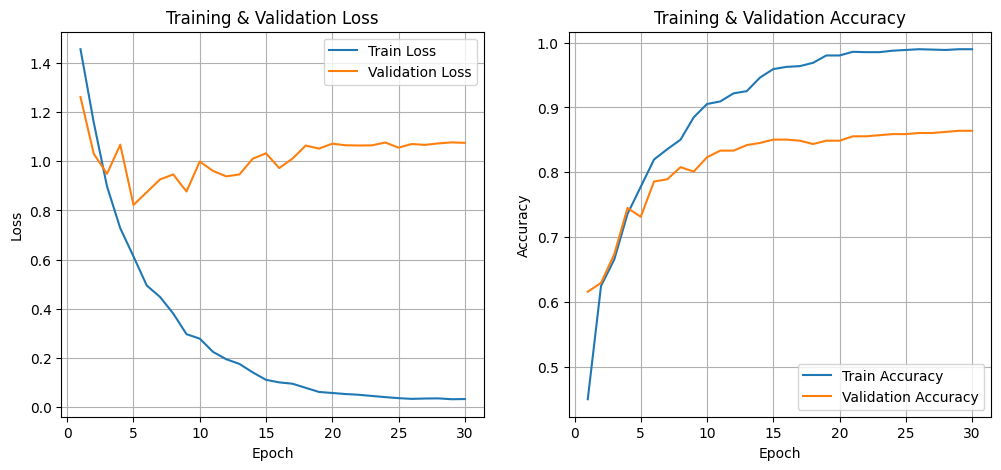

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.94      0.94      0.94       326
   beethoven       0.74      0.81      0.77        96
     debussy       0.64      0.52      0.57        31
   scarlatti       0.80      0.77      0.79        88
    victoria       0.98      0.89      0.93        47

    accuracy                           0.87       588
   macro avg       0.82      0.79      0.80       588
weighted avg       0.87      0.87      0.87       588



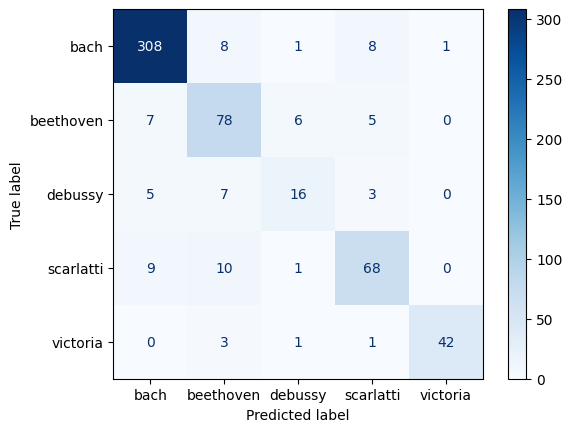

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed_x)
        hidden = hidden.view(self.num_layers, 2, x.size(0), self.hidden_size)

        forward_hidden = hidden[-1, 0, :, :]
        backward_hidden = hidden[-1, 1, :, :]

        x = torch.cat((forward_hidden, backward_hidden), dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifier(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=30)

100%|██████████| 56/56 [00:16<00:00,  3.38it/s]


(Epoch 1/[train]) Loss:	1.440   Accuracy: 0.452   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.65it/s]


(Epoch 1/[val]) Loss:	1.238   Accuracy: 0.612   lr: 0.00025


100%|██████████| 56/56 [00:16<00:00,  3.35it/s]


...

(Epoch 29/[val]) Loss:	1.027   Accuracy: 0.840   lr: 9.291796067500633e-05


100%|██████████| 56/56 [00:16<00:00,  3.44it/s]


(Epoch 30/[train]) Loss:	0.087   Accuracy: 0.970   lr: 0.00011122786419517233


100%|██████████| 19/19 [00:02<00:00,  8.92it/s]

(Epoch 30/[val]) Loss:	1.078   Accuracy: 0.832   lr: 0.00011122786419517233


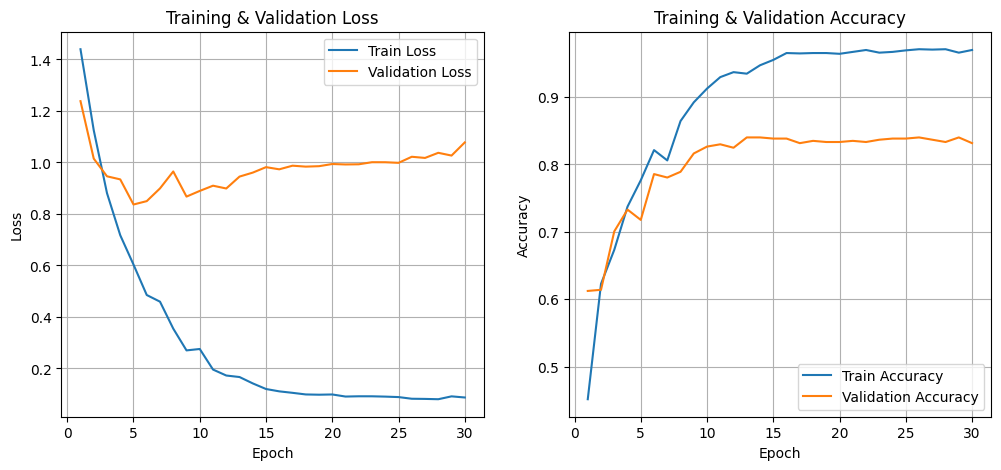

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.95      0.91      0.93       326
   beethoven       0.70      0.84      0.77        96
     debussy       0.61      0.61      0.61        31
   scarlatti       0.83      0.78      0.81        88
    victoria       0.91      0.89      0.90        47

    accuracy                           0.87       588
   macro avg       0.80      0.81      0.80       588
weighted avg       0.87      0.87      0.87       588



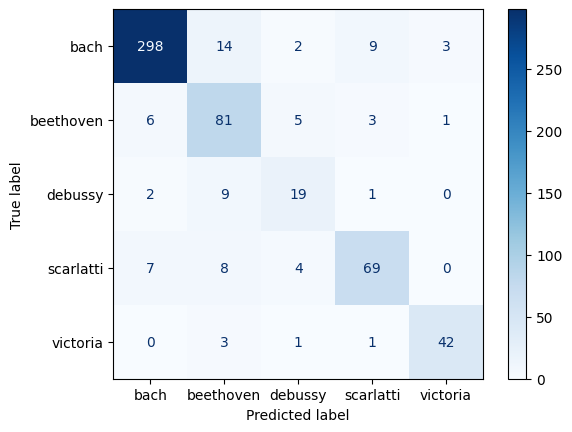

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU + more layers

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifier(256,64,256,3,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=25)

100%|██████████| 56/56 [00:23<00:00,  2.39it/s]


(Epoch 1/[train]) Loss:	1.401   Accuracy: 0.546   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  6.52it/s]


(Epoch 1/[val]) Loss:	1.121   Accuracy: 0.622   lr: 0.00025


100%|██████████| 56/56 [00:23<00:00,  2.39it/s]


...

(Epoch 24/[val]) Loss:	1.119   Accuracy: 0.842   lr: 2.307921709739586e-05


100%|██████████| 56/56 [00:23<00:00,  2.43it/s]


(Epoch 25/[train]) Loss:	0.050   Accuracy: 0.986   lr: 3.2917960675006305e-05


100%|██████████| 19/19 [00:02<00:00,  6.65it/s]

(Epoch 25/[val]) Loss:	1.164   Accuracy: 0.842   lr: 3.2917960675006305e-05


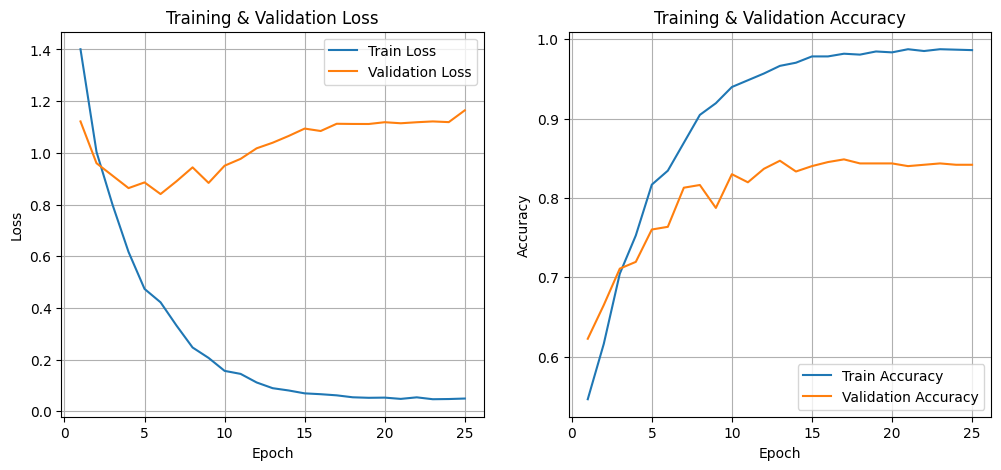

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.93      0.95      0.94       326
   beethoven       0.74      0.75      0.75        96
     debussy       0.50      0.48      0.49        31
   scarlatti       0.76      0.74      0.75        88
    victoria       0.93      0.83      0.88        47

    accuracy                           0.85       588
   macro avg       0.77      0.75      0.76       588
weighted avg       0.85      0.85      0.85       588



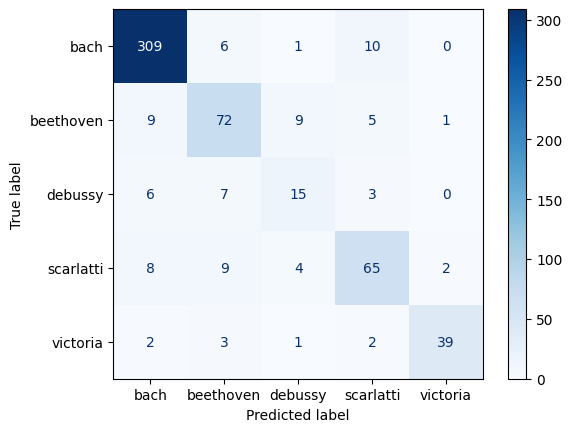

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU + mean

In [ ]:
class GRUClassifierV2(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] < lengths[:, None]
        mask = mask.unsqueeze(-1).float()
        out = out * mask
        x = out.sum(dim=1) / lengths.unsqueeze(1).float()

        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV2(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=25)

100%|██████████| 56/56 [00:20<00:00,  2.72it/s]


(Epoch 1/[train]) Loss:	1.314   Accuracy: 0.607   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  8.77it/s]


(Epoch 1/[val]) Loss:	0.938   Accuracy: 0.697   lr: 0.00025


100%|██████████| 56/56 [00:21<00:00,  2.66it/s]


...

(Epoch 24/[val]) Loss:	0.469   Accuracy: 0.876   lr: 2.307921709739586e-05


100%|██████████| 56/56 [00:21<00:00,  2.65it/s]


(Epoch 25/[train]) Loss:	0.083   Accuracy: 0.970   lr: 3.2917960675006305e-05


100%|██████████| 19/19 [00:02<00:00,  9.31it/s]


(Epoch 25/[val]) Loss:	0.480   Accuracy: 0.867   lr: 3.2917960675006305e-05


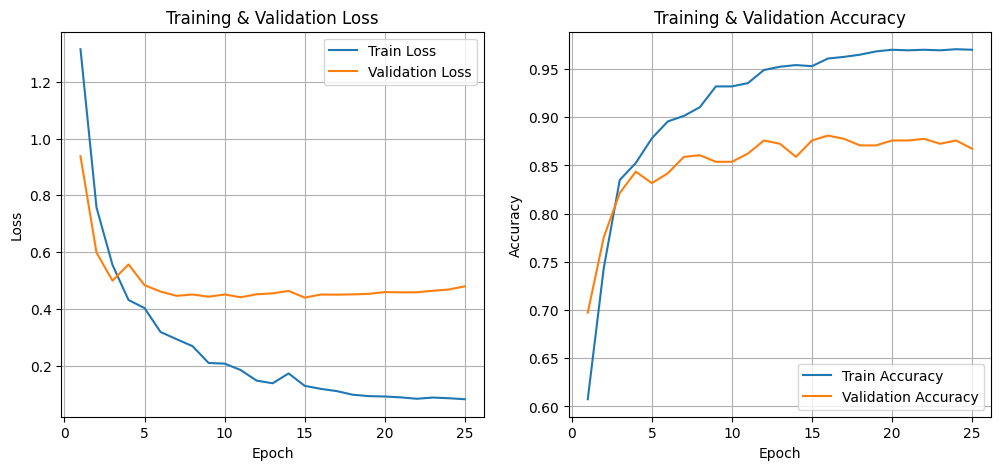

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.98      0.92      0.95       326
   beethoven       0.75      0.86      0.81        96
     debussy       0.85      0.94      0.89        31
   scarlatti       0.81      0.84      0.83        88
    victoria       0.92      0.94      0.93        47

    accuracy                           0.90       588
   macro avg       0.86      0.90      0.88       588
weighted avg       0.91      0.90      0.90       588



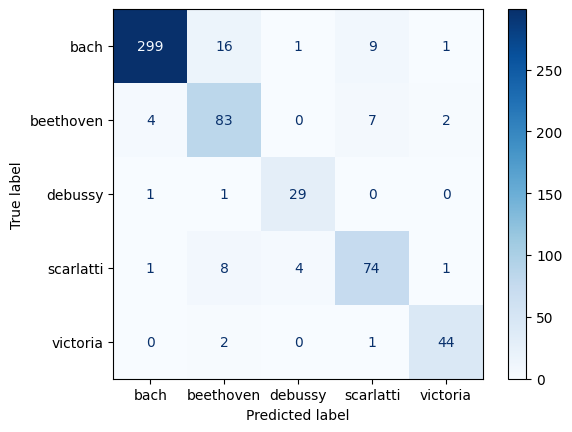

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

In [ ]:
# Zwiększenie weight_decay, zmniejszenie hidden_size

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV2(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-1)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:24<00:00,  2.27it/s]


(Epoch 1/[train]) Loss:	1.465   Accuracy: 0.592   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.74it/s]


(Epoch 1/[val]) Loss:	1.269   Accuracy: 0.685   lr: 0.00025


100%|██████████| 56/56 [00:17<00:00,  3.15it/s]


...

(Epoch 19/[val]) Loss:	0.430   Accuracy: 0.859   lr: 1.5873218044581582e-05


100%|██████████| 56/56 [00:16<00:00,  3.39it/s]


(Epoch 20/[train]) Loss:	0.151   Accuracy: 0.955   lr: 1.1477399128583483e-05


100%|██████████| 19/19 [00:01<00:00,  9.74it/s]

(Epoch 20/[val]) Loss:	0.428   Accuracy: 0.855   lr: 1.1477399128583483e-05


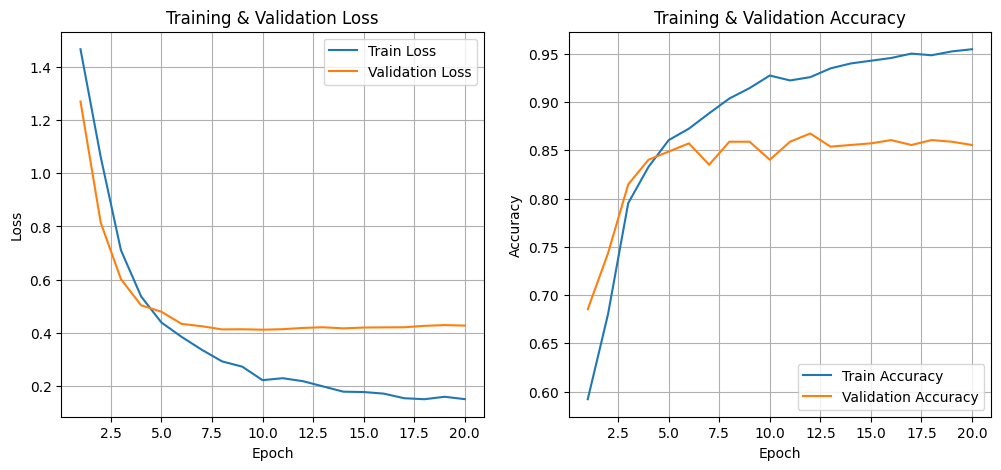

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.99      0.93      0.96       326
   beethoven       0.75      0.82      0.78        96
     debussy       0.75      0.97      0.85        31
   scarlatti       0.83      0.77      0.80        88
    victoria       0.87      0.96      0.91        47

    accuracy                           0.89       588
   macro avg       0.84      0.89      0.86       588
weighted avg       0.90      0.89      0.90       588



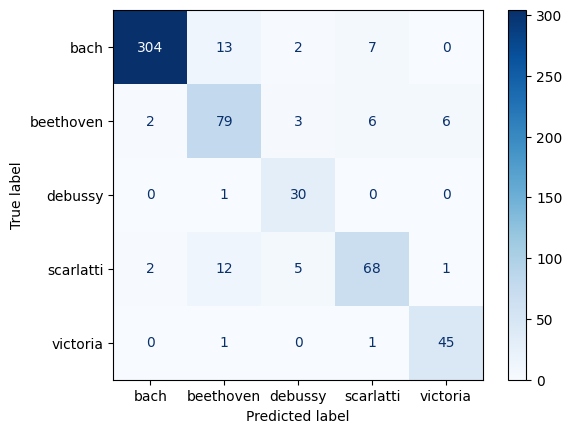

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU + attention

In [ ]:
class GRUClassifierV3(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(0.4)
        self.attention = nn.Linear(hidden_size*2, 1)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        scores = self.attention(out).squeeze(-1)
        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] >= lengths[:, None]
        scores = scores.masked_fill(mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        x = torch.sum(out * weights.unsqueeze(-1), dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV3(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=25)

100%|██████████| 56/56 [00:21<00:00,  2.66it/s]


(Epoch 1/[train]) Loss:	0.908   Accuracy: 0.659   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  7.18it/s]


(Epoch 1/[val]) Loss:	0.578   Accuracy: 0.793   lr: 0.00025


100%|██████████| 56/56 [00:21<00:00,  2.65it/s]


...

(Epoch 24/[val]) Loss:	0.442   Accuracy: 0.884   lr: 2.307921709739586e-05


100%|██████████| 56/56 [00:21<00:00,  2.62it/s]


(Epoch 25/[train]) Loss:	0.092   Accuracy: 0.966   lr: 3.2917960675006305e-05


100%|██████████| 19/19 [00:02<00:00,  9.11it/s]

(Epoch 25/[val]) Loss:	0.442   Accuracy: 0.884   lr: 3.2917960675006305e-05


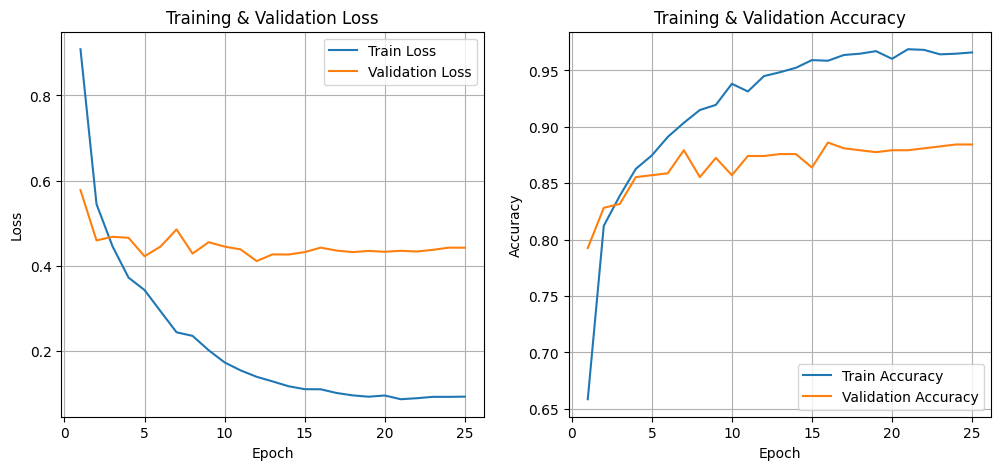

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.93      0.95       326
   beethoven       0.79      0.85      0.82        96
     debussy       0.88      0.94      0.91        31
   scarlatti       0.87      0.83      0.85        88
    victoria       0.85      0.96      0.90        47

    accuracy                           0.91       588
   macro avg       0.87      0.90      0.89       588
weighted avg       0.91      0.91      0.91       588



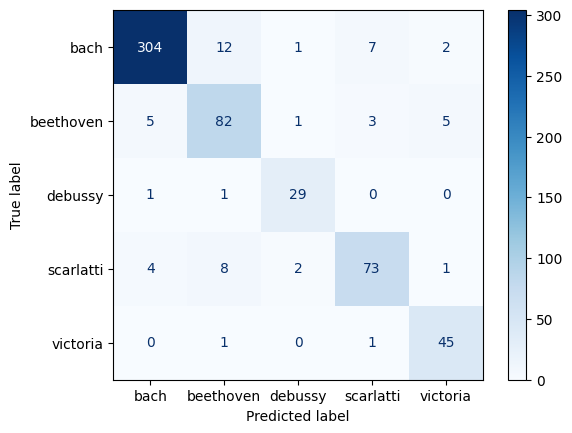

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

In [ ]:
# ##Czyszczenie gpu, jakby było potrzebne
# import gc
# import torch

# del model
# del optimizer
# gc.collect()
# torch.cuda.empty_cache()

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### GRU + mean + attention

In [ ]:
class GRUClassifierV4(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(0.4)
        self.attention = nn.Linear(hidden_size*2, 1)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        scores = self.attention(out).squeeze(-1)
        mask_attn = torch.arange(out.size(1)).to(lengths.device)[None, :] >= lengths[:, None]
        scores = scores.masked_fill(mask_attn, -1e9)
        weights = torch.softmax(scores, dim=1)

        mask_mean = torch.arange(out.size(1)).to(lengths.device)[None, :] < lengths[:, None]
        mask_mean = mask_mean.unsqueeze(-1).float()
        mean_out = out * mask_mean
        mean_pool = mean_out.sum(dim=1) / lengths.unsqueeze(1).float()
        attn_pool = torch.sum(out * weights.unsqueeze(-1), dim=1)

        x = mean_pool + attn_pool
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

X_train_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_train]
X_val_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_val]
X_test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in X_test]

X_train_p = pad_sequence(X_train_emb, batch_first=True, padding_value=0)
X_val_p = pad_sequence(X_val_emb, batch_first=True, padding_value=0)
X_test_p = pad_sequence(X_test_emb, batch_first=True, padding_value=0)

emb_datasets = {
    'train': data.TensorDataset(X_train_p, X_train_lengths, y_train_tensor),
    'val': data.TensorDataset(X_val_p, X_val_lengths, y_val_tensor),
    'test': data.TensorDataset(X_test_p, X_test_lengths, y_test_tensor)
}

emb_loaders = {split: data.DataLoader(emb_datasets[split], batch_size=32, shuffle=split=='train') for split in emb_datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV4(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=30)

100%|██████████| 56/56 [00:21<00:00,  2.61it/s]


(Epoch 1/[train]) Loss:	0.914   Accuracy: 0.657   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  9.24it/s]


(Epoch 1/[val]) Loss:	0.591   Accuracy: 0.796   lr: 0.00025


100%|██████████| 56/56 [00:20<00:00,  2.68it/s]


...

(Epoch 29/[val]) Loss:	0.482   Accuracy: 0.878   lr: 9.291796067500633e-05


100%|██████████| 56/56 [00:21<00:00,  2.62it/s]


(Epoch 30/[train]) Loss:	0.110   Accuracy: 0.955   lr: 0.00011122786419517233


100%|██████████| 19/19 [00:02<00:00,  9.39it/s]

(Epoch 30/[val]) Loss:	0.448   Accuracy: 0.876   lr: 0.00011122786419517233


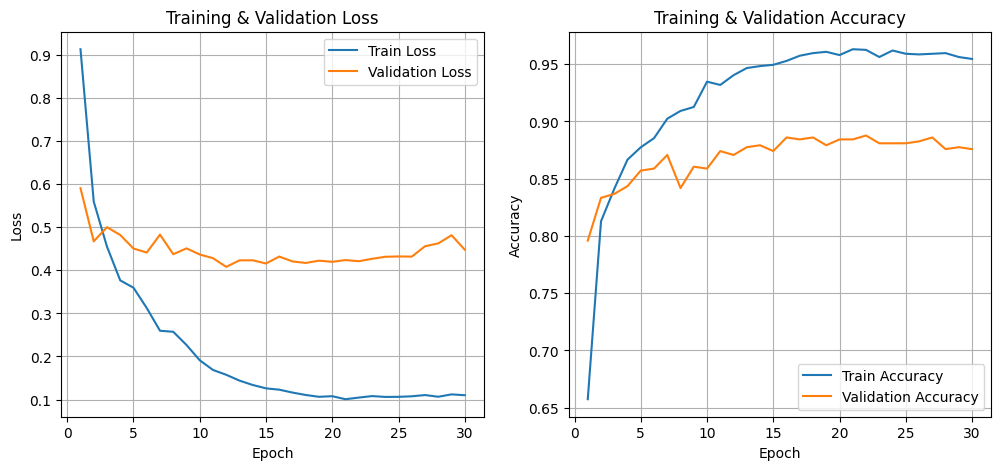

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.98      0.93      0.96       326
   beethoven       0.83      0.82      0.83        96
     debussy       0.82      1.00      0.90        31
   scarlatti       0.85      0.89      0.87        88
    victoria       0.82      0.96      0.88        47

    accuracy                           0.91       588
   macro avg       0.86      0.92      0.89       588
weighted avg       0.92      0.91      0.91       588



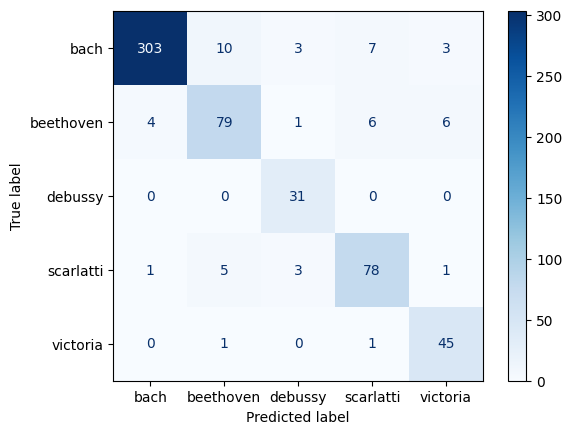

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU + attention + smaller model

In [31]:
class GRUClassifierV5(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(0.4)
        self.attention = nn.Linear(hidden_size*2, 1)
        self.fc1 = nn.Linear(hidden_size*2, hidden_size)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        scores = self.attention(out).squeeze(-1)
        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] >= lengths[:, None]
        scores = scores.masked_fill(mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        x = torch.sum(out * weights.unsqueeze(-1), dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [42]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model = GRUClassifierV5(256,64,128,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-2)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=40)

100%|██████████| 56/56 [00:23<00:00,  2.41it/s]


(Epoch 1/[train]) Loss:	1.367   Accuracy: 0.501   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.67it/s]


(Epoch 1/[val]) Loss:	0.930   Accuracy: 0.723   lr: 0.00025


100%|██████████| 56/56 [00:18<00:00,  3.09it/s]


...

(Epoch 14/[val]) Loss:	0.384   Accuracy: 0.862   lr: 2.037454508288789e-05


100%|██████████| 56/56 [00:17<00:00,  3.25it/s]


(Epoch 15/[train]) Loss:	0.199   Accuracy: 0.925   lr: 1.262228791194332e-05


100%|██████████| 19/19 [00:02<00:00,  7.64it/s]

(Epoch 15/[val]) Loss:	0.384   Accuracy: 0.861   lr: 1.262228791194332e-05

Early stopping at epoch 15


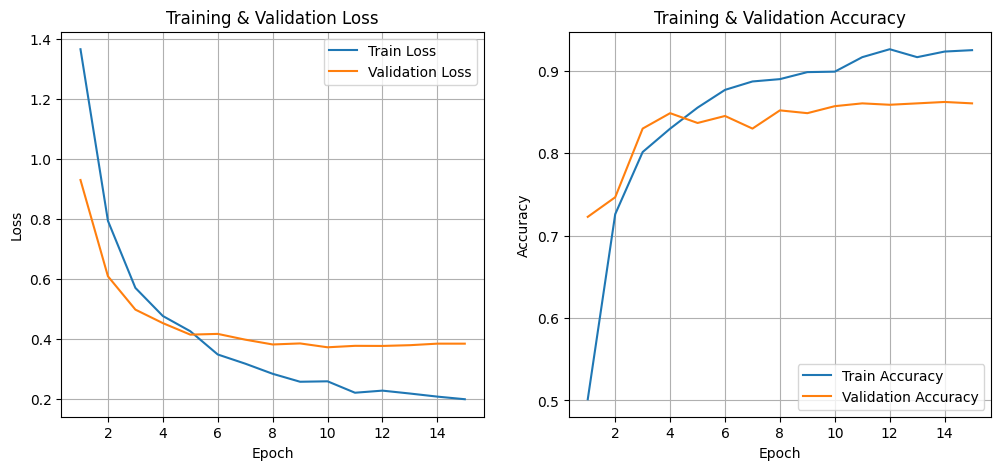

In [43]:
plot_training_curves(metrics)

In [44]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.98      0.90      0.94       326
   beethoven       0.76      0.84      0.80        96
     debussy       0.78      0.94      0.85        31
   scarlatti       0.80      0.85      0.82        88
    victoria       0.86      0.94      0.90        47

    accuracy                           0.89       588
   macro avg       0.84      0.89      0.86       588
weighted avg       0.90      0.89      0.89       588



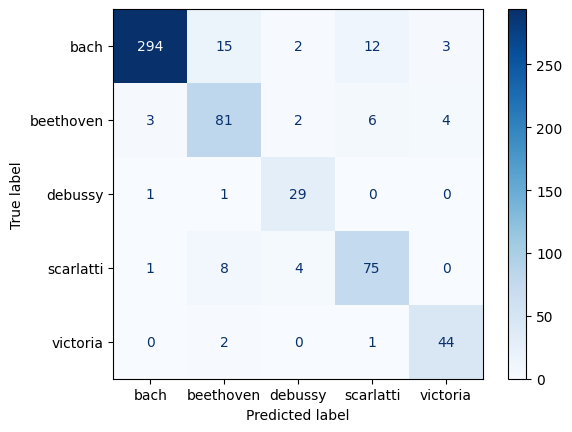

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

### GRU + attention + bigger classificator

In [52]:
class GRUClassifierV5(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_size, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=True,
                            dropout=0.4 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(0.4)
        self.attention = nn.Linear(hidden_size*2, 1)
        self.fc1 = nn.Linear(hidden_size*2, hidden_size)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed_x = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.gru(packed_x)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        scores = self.attention(out).squeeze(-1)
        mask = torch.arange(out.size(1)).to(lengths.device)[None, :] >= lengths[:, None]
        scores = scores.masked_fill(mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        x = torch.sum(out * weights.unsqueeze(-1), dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [53]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV5(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-3)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=20)

100%|██████████| 56/56 [00:20<00:00,  2.74it/s]


(Epoch 1/[train]) Loss:	1.077   Accuracy: 0.598   lr: 0.00025


100%|██████████| 19/19 [00:01<00:00,  9.63it/s]


(Epoch 1/[val]) Loss:	0.610   Accuracy: 0.747   lr: 0.00025


100%|██████████| 56/56 [00:19<00:00,  2.80it/s]


...

(Epoch 13/[val]) Loss:	0.362   Accuracy: 0.879   lr: 9.291796067500636e-05


100%|██████████| 56/56 [00:20<00:00,  2.77it/s]


(Epoch 14/[train]) Loss:	0.100   Accuracy: 0.956   lr: 7.552114003125443e-05


100%|██████████| 19/19 [00:01<00:00,  9.55it/s]

(Epoch 14/[val]) Loss:	0.381   Accuracy: 0.874   lr: 7.552114003125443e-05

Early stopping at epoch 14


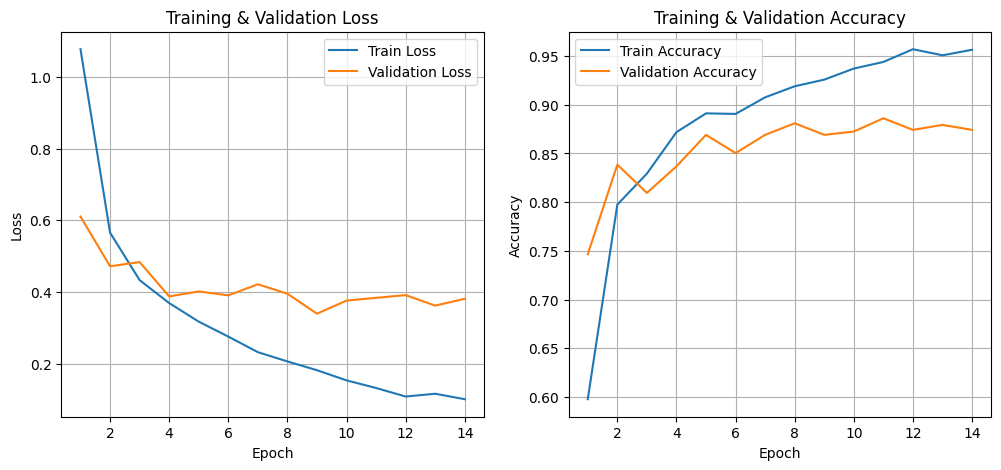

In [54]:
plot_training_curves(metrics)

In [55]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.94      0.95       326
   beethoven       0.79      0.83      0.81        96
     debussy       0.88      0.94      0.91        31
   scarlatti       0.89      0.84      0.87        88
    victoria       0.85      0.96      0.90        47

    accuracy                           0.91       588
   macro avg       0.88      0.90      0.89       588
weighted avg       0.91      0.91      0.91       588



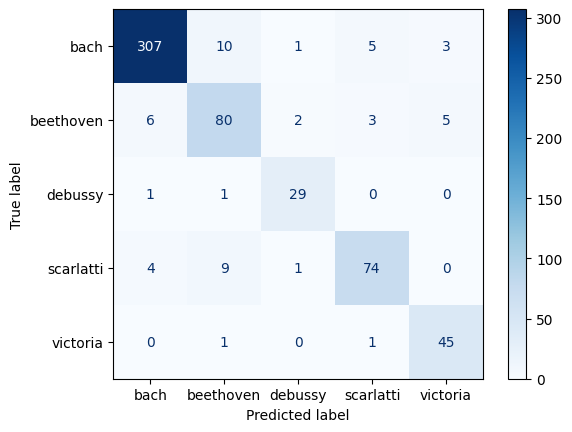

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

In [63]:
# Early stopping + większe weight_decay
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
model = GRUClassifierV5(256,64,256,2,5).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-1)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

metrics = train(model, emb_loaders, criterion, optimizer, lr_scheduler, num_epochs=25)

100%|██████████| 56/56 [00:19<00:00,  2.83it/s]


(Epoch 1/[train]) Loss:	1.078   Accuracy: 0.598   lr: 0.00025


100%|██████████| 19/19 [00:02<00:00,  7.83it/s]


(Epoch 1/[val]) Loss:	0.611   Accuracy: 0.747   lr: 0.00025


100%|██████████| 56/56 [00:19<00:00,  2.84it/s]


...

(Epoch 13/[val]) Loss:	0.380   Accuracy: 0.866   lr: 3.2917960675006325e-05


100%|██████████| 56/56 [00:20<00:00,  2.76it/s]


(Epoch 14/[train]) Loss:	0.117   Accuracy: 0.954   lr: 2.037454508288789e-05


100%|██████████| 19/19 [00:01<00:00,  9.58it/s]

(Epoch 14/[val]) Loss:	0.379   Accuracy: 0.872   lr: 2.037454508288789e-05

Early stopping at epoch 14


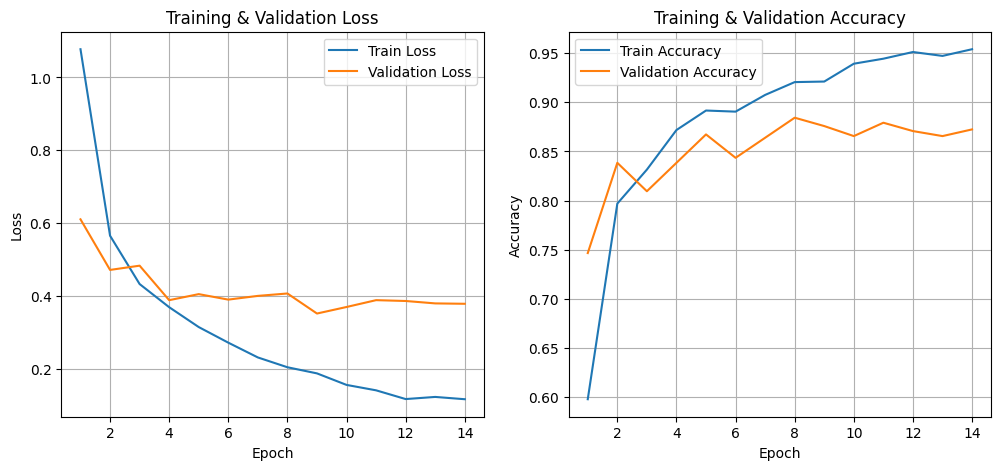

In [64]:
plot_training_curves(metrics)

In [65]:
preds, targets = get_predictions(model, emb_loaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

        bach       0.97      0.94      0.95       326
   beethoven       0.80      0.83      0.82        96
     debussy       0.88      0.97      0.92        31
   scarlatti       0.87      0.85      0.86        88
    victoria       0.85      0.94      0.89        47

    accuracy                           0.91       588
   macro avg       0.87      0.91      0.89       588
weighted avg       0.91      0.91      0.91       588



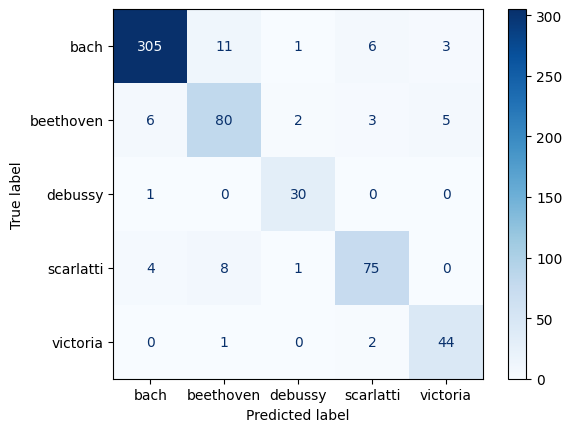

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

## Generowanie wyników

Do wygenerowania ostatecznych wyników wyybrano model:
```
GRUClassifierV5(
      num_embeddings=256,
      embedding_dim=64,
      hidden_size=256,
      num_layers=2,
      num_classes=5
  )
```

In [67]:
point = test[0]

print(f"Sekwencja: {point[:10]} ...")

Sekwencja: [  0.   0.   0.   0.  88.  88.  88.  88.  69. 145.] ...


In [68]:
test_emb = [torch.tensor(seq + 1, dtype=torch.long) for seq in test]
test_p = pad_sequence(test_emb, batch_first=True, padding_value=0)

test_lengths = torch.tensor([len(seq) for seq in test], dtype=torch.long)
test_dataset = data.TensorDataset(test_p, test_lengths)
test_loader = data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [69]:
model.eval()

test_predictions_list = []

with torch.inference_mode():
    for X_batch_test, lengths_test in tqdm(test_loader, desc="Generating test predictions"):
        X_batch_test = X_batch_test.to(device)
        lengths_test = lengths_test.to(device)

        logits = model(X_batch_test, lengths_test)

        _, predicted_classes = torch.max(logits, dim=1)
        test_predictions_list.extend(predicted_classes.cpu().numpy())

final_test_predictions = np.array(test_predictions_list)
print()
print(final_test_predictions)

Generating test predictions: 100%|██████████| 35/35 [00:03<00:00, 10.58it/s]


[0 3 0 ... 3 2 4]


Text(0, 0.5, 'Ilość wystąpień')

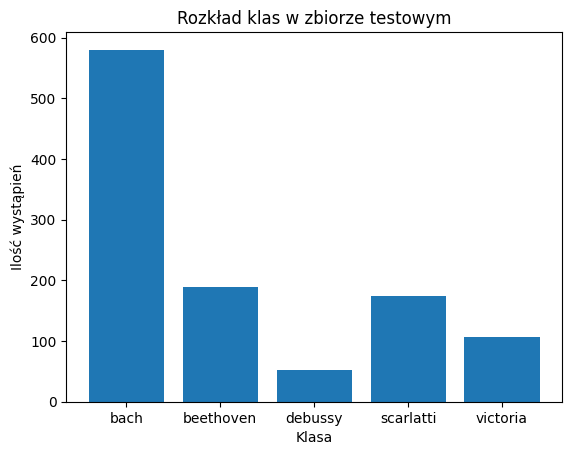

In [70]:
unique_classes, counts = np.unique(test_predictions_list, return_counts=True)
num_classes = 5

plt.bar(unique_classes, counts, tick_label=[class_names[c] for c in unique_classes], width=0.8, align='center')

plt.title('Rozkład klas w zbiorze testowym')
plt.xlabel('Klasa')
plt.ylabel('Ilość wystąpień')


In [71]:
results = pd.DataFrame({
    "prediction": test_predictions_list
})


In [72]:
results.to_csv("pred.csv", index=False, header=False)